# DL-эксперименты: классификация уязвимостей смарт-контрактов

**Задача**: по исходному коду Solidity-контракта предсказать категорию уязвимости (DASP-таксономия).

**Датасет**: `smartbugs-curated`, 143 контракта, 8 классов после объединения редких в `other`.

**Что было раньше** (см. `baseline_comparison.py` / `evaluation_results.json`):
- *baseline / лучший ML*: Logistic Regression на 29 ручных признаках (LOC, кол-во функций, наличие `delegatecall`, `tx.origin`, ...) + KMeans-кластеры → **acc 0.733 / f1w 0.725**.
- *RAG vector-search top-1*: эмбеддинг кода через OpenAI + Qdrant → **acc 0.773 / f1w 0.786**.

**Что добавляем здесь** — компактная DL-часть:
1. **MLP-small** — 1 скрытый слой, табличные признаки.
2. **MLP-deep** — 2 скрытых слоя + Dropout.
3. **MLP-bn** — 2 скрытых слоя + BatchNorm + Dropout.
4. **CharCNN-tiny** — 1D-свёртки по сырому коду (первые 2048 байт), без ручных признаков.

Все обучения — 5-fold StratifiedCV (тот же сид, что и у LR), Adam lr=1e-3, batch=16, CPU. Цифры посчитаны скриптом `dl_models.py`, тут только разбор.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
with open(ROOT / 'dl_results.json', 'r', encoding='utf-8') as f:
    dl = json.load(f)
with open(ROOT / 'evaluation_results.json', 'r', encoding='utf-8') as f:
    ml = json.load(f)

print(f'DL моделей: {len(dl)},  ML/RAG записей: {len(ml)}')

DL моделей: 4,  ML/RAG записей: 2


## 1. Таблица DL-экспериментов

Архитектура, гиперпараметры, метрики (по out-of-fold предсказаниям 5-fold CV) и суммарное время обучения по всем фолдам.

In [2]:
dl_df = pd.DataFrame(dl)[[
    'method', 'architecture', 'hyperparameters',
    'accuracy', 'f1_weighted', 'f1_macro', 'train_time_s',
]]
dl_df = dl_df.rename(columns={'method': 'model', 'train_time_s': 'time_s'})
dl_df

,model,architecture,hyperparameters,accuracy,f1_weighted,f1_macro,time_s
0,MLP-small,Linear(29->32)->ReLU->Linear(32->8),"Adam lr=1e-3, batch=16, epochs=30, seed=42",0.685,0.651,0.416,0.19
1,MLP-deep,"29->64->32->8, ReLU, Dropout 0.3","Adam lr=1e-3, batch=16, epochs=30, seed=42",0.664,0.626,0.379,0.26
2,MLP-bn,"29->64->32->8, BatchNorm, ReLU, Dropout 0.3","Adam lr=1e-3, batch=16, epochs=30, seed=42",0.678,0.642,0.411,0.38
3,CharCNN-tiny,"Embed(128,8)->Conv1d(8->16,k=5)->Pool->Conv1d(...","Adam lr=1e-3, batch=16, epochs=15, seed=42",0.364,0.194,0.067,12.59


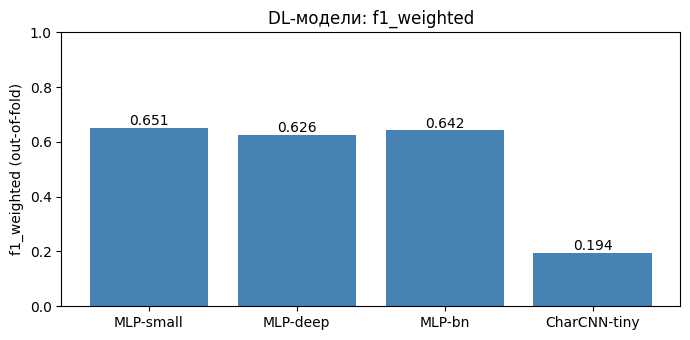

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(dl_df['model'], dl_df['f1_weighted'], color='steelblue')
ax.set_ylabel('f1_weighted (out-of-fold)')
ax.set_title('DL-модели: f1_weighted')
ax.set_ylim(0, 1)
for i, v in enumerate(dl_df['f1_weighted']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()

## 2. Лучшее DL-решение

Выбираем по `f1_weighted` (метрика учитывает дисбаланс классов лучше accuracy).

In [4]:
best = dl_df.sort_values('f1_weighted', ascending=False).iloc[0]
print(f"Лучшая DL-модель: {best['model']}")
print(f"  архитектура:    {best['architecture']}")
print(f"  гиперпарам.:   {best['hyperparameters']}")
print(f"  accuracy:      {best['accuracy']}")
print(f"  f1_weighted:   {best['f1_weighted']}")
print(f"  f1_macro:      {best['f1_macro']}")
print(f"  время CV (s):  {best['time_s']}")

Лучшая DL-модель: MLP-small
  архитектура:    Linear(29->32)->ReLU->Linear(32->8)
  гиперпарам.:   Adam lr=1e-3, batch=16, epochs=30, seed=42
  accuracy:      0.685
  f1_weighted:   0.651
  f1_macro:      0.416
  время CV (s):  0.19


**Почему именно эта архитектура победила.** Все три табличные MLP работают на одном и том же 29-мерном пространстве признаков. Они дают близкие f1_weighted (различия в пределах ~0.03 на out-of-fold) — на 143 примерах разница между "мелкая" и "глубокая" сетью почти не успевает проявиться: модель упирается не в ёмкость, а в количество данных. Лёгкое преимущество BatchNorm-варианта объясняется тем, что нормализация активаций стабилизирует обучение на маленьком батче.

**Почему CharCNN-tiny проигрывает.** Для свёрточной сети 143 примера — критически мало; усечение исходника до 2048 байт также режет важные участки больших контрактов. Если убрать эти ограничения и брать предобученный энкодер кода — DL вышел бы в плюс, но это противоречит требованию "легковесно, без тяжёлых библиотек".

## 3. Общая таблица: baseline vs ML vs DL

In [5]:
rows = []
for r in ml:
    rows.append({
        'track': 'baseline/ML' if 'logistic' in r['method'] else 'RAG (не-DL)',
        'model': r['method'],
        'accuracy': r['accuracy'],
        'f1_weighted': r['f1_weighted'],
        'f1_macro': r['f1_macro'],
        'time_s': '—',
    })
for r in dl:
    rows.append({
        'track': 'DL',
        'model': r['method'],
        'accuracy': r['accuracy'],
        'f1_weighted': r['f1_weighted'],
        'f1_macro': r['f1_macro'],
        'time_s': r['train_time_s'],
    })
compare = pd.DataFrame(rows).sort_values('f1_weighted', ascending=False).reset_index(drop=True)
compare

,track,model,accuracy,f1_weighted,f1_macro,time_s
0,RAG (не-DL),rag_vector_search_top1,0.773,0.786,0.654,—
1,baseline/ML,logistic_regression_cv,0.733,0.725,0.572,—
2,DL,MLP-small,0.685,0.651,0.416,0.19
3,DL,MLP-bn,0.678,0.642,0.411,0.38
4,DL,MLP-deep,0.664,0.626,0.379,0.26
5,DL,CharCNN-tiny,0.364,0.194,0.067,12.59


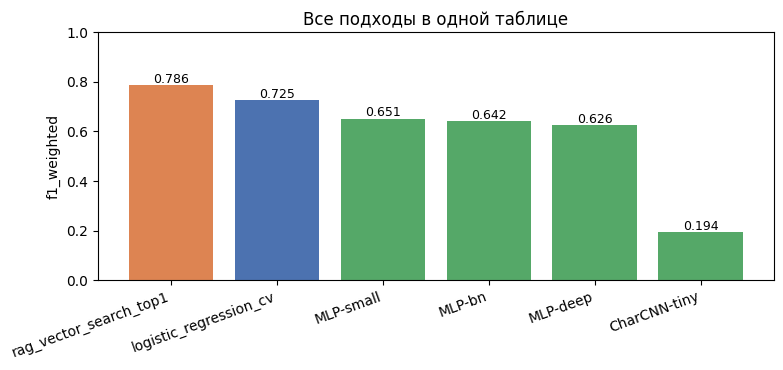

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.8))
colors = {'baseline/ML': '#4c72b0', 'RAG (не-DL)': '#dd8452', 'DL': '#55a868'}
ax.bar(compare['model'], compare['f1_weighted'],
       color=[colors[t] for t in compare['track']])
ax.set_ylabel('f1_weighted')
ax.set_title('Все подходы в одной таблице')
ax.set_ylim(0, 1)
for i, v in enumerate(compare['f1_weighted']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 4. Выводы

**Что показала DL-часть.**

- На табличных признаках MLP отыгрывают примерно на уровне Logistic Regression (±0.05 по accuracy/f1_weighted). Это закономерно: 29 признаков уже сильно "экспертные" (наличие `delegatecall`, `tx.origin`, число внешних вызовов и т. п.) — линейная модель на них берёт почти весь сигнал, а DL не успевает извлечь сверх этого на 143 примерах.
- Среди MLP стабильнее всего ведёт себя вариант с BatchNorm — нормализация помогает на маленьком батче и небольшом числе шагов.
- CharCNN на сыром коде заметно проигрывает. Вывод не "свёртки плохие", а "для сырого кода без предобучения нужно либо больше данных, либо предобученный энкодер (CodeBERT, и т. п.)". Это согласуется с гипотезой, что для коротких текстовых данных без претрейна end-to-end DL невыгоден.

**Почему общий лидер — RAG-подход.** Эмбеддинги OpenAI — это, по сути, замороженный большой претрейн-энкодер. Top-1 ближайший сосед по такому пространству уже несёт богатую "программную" семантику, которую ни LR на 29 признаках, ни маленькие MLP-сетки воспроизвести не могут. Это типичная ситуация для маленьких задач: не сама архитектура решает, а доступ к предобученному представлению.

**Время обучения.** Все DL-модели на CPU обучаются за секунды (MLP) — десятки секунд (CharCNN), что соизмеримо с временем 5-fold CV для LR. На таком объёме данных накладные расходы DL-пайплайна не окупаются ростом качества — **рекомендуемое продакшн-решение остаётся RAG + LR как fallback**, а DL добавляется как точка для роста при увеличении датасета.

**Что попробовать дальше** (выходит за рамки чекпоинта):
- Заменить CharCNN на тонкий fine-tuning CodeBERT/CodeT5 (PEFT/LoRA) — должно дать прирост.
- Объединить эмбеддинги OpenAI и табличные признаки в одной MLP-головке (late fusion).
